In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from utils import one_hot_encode, apply_pca

RANDOM_STATE = 36

In [2]:
df = pd.read_csv('Housing.csv')
print(df.shape)
df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Removing Irrelevant Data

In [3]:
df = df.drop(['basement', 'hotwaterheating', 'guestroom', 'mainroad', 'furnishingstatus'], axis=1)
df.head()

,price,area,bedrooms,bathrooms,stories,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,yes,2,yes
1,12250000,8960,4,4,4,yes,3,no
2,12250000,9960,3,2,2,no,2,yes
3,12215000,7500,4,2,2,yes,3,yes
4,11410000,7420,4,1,2,yes,2,no


In [4]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'airconditioning',
       'parking', 'prefarea'],
      dtype='str')

# One Hot Encoding

In [5]:
columns_to_encode = ['airconditioning', 'prefarea']
df = one_hot_encode(df, *columns_to_encode)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes
0,13300000,7420,4,2,3,2,0.0,1.0,0.0,1.0
1,12250000,8960,4,4,4,3,0.0,1.0,1.0,0.0
2,12250000,9960,3,2,2,2,1.0,0.0,0.0,1.0
3,12215000,7500,4,2,2,3,0.0,1.0,0.0,1.0
4,11410000,7420,4,1,2,2,0.0,1.0,1.0,0.0


# Decreasing Features for Visualization
## With Applying PCA

In [6]:
df_pca, pca = apply_pca(df)
print('Shape:', df_pca.shape, '\nVariance Ratio:', pca.explained_variance_ratio_)


Shape: (545, 2) 
Variance Ratio: [9.99999041e-01 9.59397788e-07]


# Visualizing using PCA

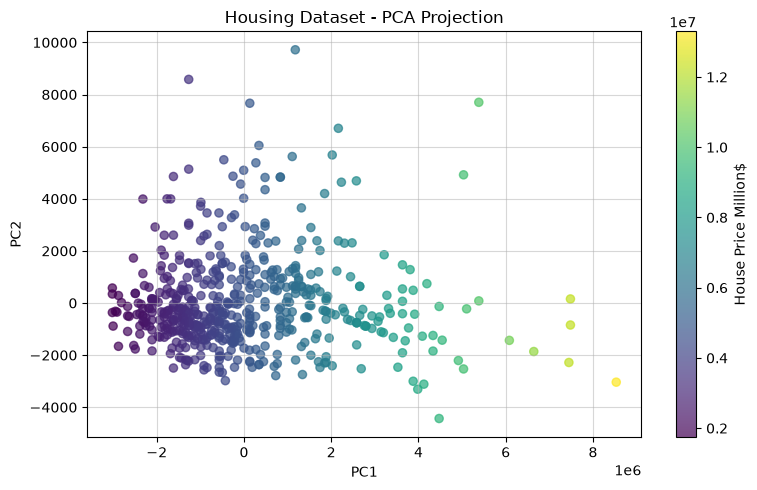

In [7]:
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=df["price"],
    cmap="viridis",
    alpha=0.7,
    s=35
)

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("Housing Dataset - PCA Projection")

plt.colorbar(scatter, label="House Price Million$")
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
y = df['price']
x = df.drop('price', axis=1)

x_train, x_cv, y_train, y_cv = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
print(x_train.shape, y_train.shape, x_cv.shape, y_cv.shape)

(436, 9) (436,) (109, 9) (109,)


In [ ]:
scaler = 